# 03 - Customer Segmentation using K-Means Clustering
### Customer Churn Prediction in the Banking Sector

This notebook performs **customer segmentation** using K-Means clustering, following the
paper's approach:

1. Load the processed dataset (from notebook 02)
2. Select features for clustering (drop the target `Attrition_Flag` — clustering is unsupervised)
3. Use the **Elbow Method** to choose the optimal number of clusters (k)
4. Fit K-Means with the chosen k
5. Assign each customer a `Cluster` label
6. Profile each cluster (mean feature values, churn rate per cluster)
7. Save the segmented dataset for use in notebook 04 (modeling with vs without segmentation)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

try:
    from yellowbrick.cluster import KElbowVisualizer
    HAS_YELLOWBRICK = True
except ImportError:
    HAS_YELLOWBRICK = False
    print("yellowbrick not installed - will use manual elbow plot instead.")

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Load Processed Data

In [2]:
DATA_PATH = "../data/processed/churn_processed.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7081, 20)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,-0.167610,1,3,High School,Married,$60K - $80K,Blue,0.377234,5,1,3,0.340190,0.308701,0.345116,1.335,0.036260,0.258065,1.625,0.061
1,0,0.329862,0,5,Graduate,Single,Less than $40K,Blue,1.002074,6,1,2,0.206112,0.343266,0.214093,1.541,0.044667,0.185484,3.714,0.105
2,0,0.578598,1,3,Graduate,Married,$80K - $120K,Blue,0.002330,4,1,0,0.059850,0.000000,0.098948,2.594,0.078753,0.080645,2.333,0.000
3,0,-0.789449,1,3,Uneducated,Married,$60K - $80K,Blue,-1.872192,5,1,0,0.099091,0.000000,0.136557,2.175,0.017501,0.145161,2.500,0.000
4,0,-0.291978,1,2,Graduate,Married,$40K - $60K,Blue,0.002330,3,1,2,0.077747,0.495431,0.079970,1.376,0.033057,0.112903,0.846,0.311


## 2. Select Features for Clustering

Clustering is **unsupervised**, so we exclude the target (`Attrition_Flag`). We cluster on
all the remaining (already encoded/scaled) features, matching the paper's approach of
segmenting customers before churn prediction.


In [8]:
X_cluster = df.drop(columns=['Attrition_Flag'])

# KMeans requires numeric input; drop any non-numeric columns if present.
nonnumeric_cols = X_cluster.select_dtypes(exclude=[np.number]).columns.tolist()
if nonnumeric_cols:
    print("Dropping non-numeric columns before clustering:", nonnumeric_cols)
    X_cluster = X_cluster.select_dtypes(include=[np.number])

print("Features used for clustering:", X_cluster.shape[1])
X_cluster.columns.tolist()

Dropping non-numeric columns before clustering: ['Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Features used for clustering: 15


['Customer_Age',
 'Gender',
 'Dependent_count',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

## 3. Elbow Method — Choosing Optimal K

The paper finds **k = 6** to be optimal using the distortion score elbow technique.
We reproduce that here.


c:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\adity\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\adity\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

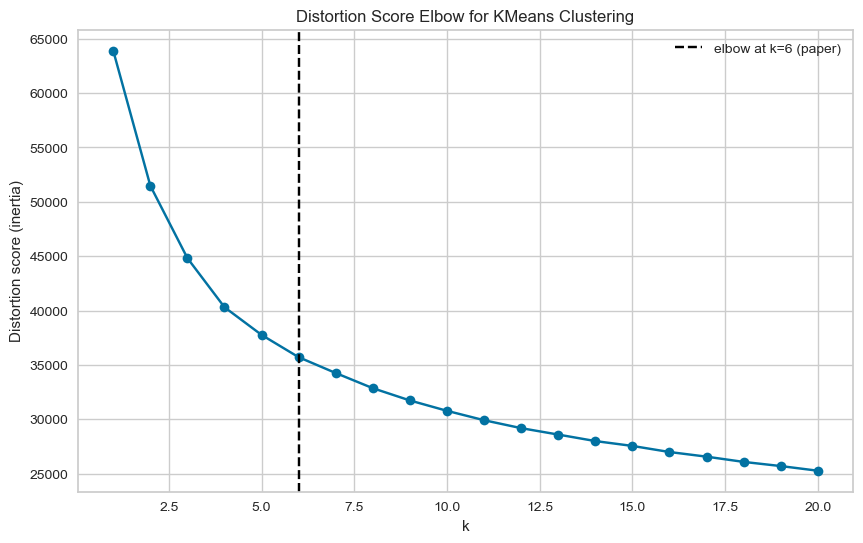

Using k = 6 (matches the elbow point reported in the paper)


In [9]:
if HAS_YELLOWBRICK:
    try:
        model = KMeans(random_state=42, n_init=10)
        visualizer = KElbowVisualizer(model, k=(1, 20), metric='distortion', timings=False)
        visualizer.fit(X_cluster)
        visualizer.show()
        optimal_k = visualizer.elbow_value_
        print("Detected optimal k:", optimal_k)

        if optimal_k is None:
            raise ValueError("Yellowbrick did not detect an elbow point")
    except Exception as e:
        print("Yellowbrick elbow detection failed:", e)
        HAS_YELLOWBRICK = False

if not HAS_YELLOWBRICK:
    distortions = []
    K_range = range(1, 21)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_cluster)
        distortions.append(km.inertia_)

    plt.plot(K_range, distortions, marker='o')
    plt.xlabel('k')
    plt.ylabel('Distortion score (inertia)')
    plt.title('Distortion Score Elbow for KMeans Clustering')
    plt.axvline(x=6, color='black', linestyle='--', label='elbow at k=6 (paper)')
    plt.legend()
    plt.show()
    optimal_k = 6
    print("Using k =", optimal_k, "(matches the elbow point reported in the paper)")


## 4. Fit K-Means with Chosen K

We use **k = 6** (matching the paper) for the final segmentation model.


In [10]:
N_CLUSTERS = 6

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

print(df['Cluster'].value_counts().sort_index())


Cluster
0    1193
1    1616
2     953
3    1044
4    1051
5    1224
Name: count, dtype: int64


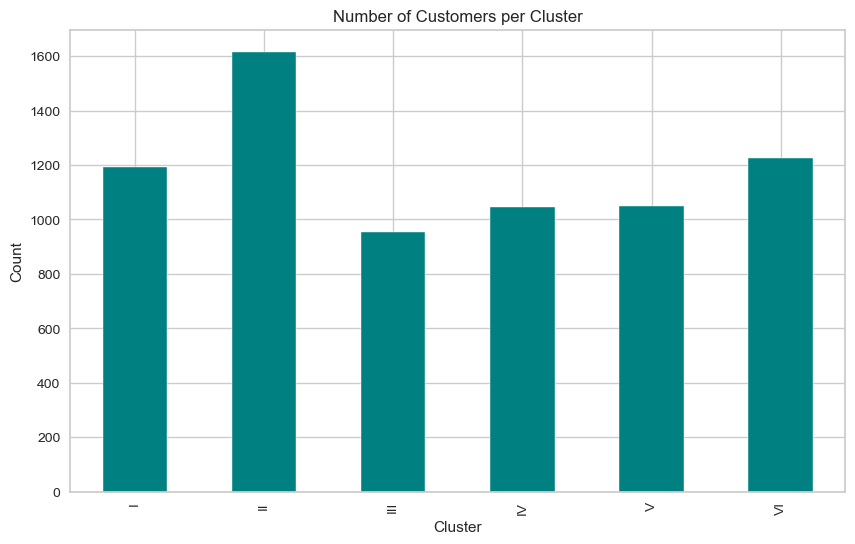

Cluster_Label
I      1193
II     1616
III     953
IV     1044
V      1051
VI     1224
Name: count, dtype: int64


In [11]:
# Map numeric cluster labels to Roman numerals (I-VI) to match the paper's naming
roman_map = {0: 'I', 1: 'II', 2: 'III', 3: 'IV', 4: 'V', 5: 'VI'}
df['Cluster_Label'] = df['Cluster'].map(roman_map)

cluster_counts = df['Cluster_Label'].value_counts().reindex(['I', 'II', 'III', 'IV', 'V', 'VI'])
cluster_counts.plot(kind='bar', color='teal')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

print(cluster_counts)


## 5. Cluster Profiling — Churn Rate per Cluster

               Total_Customers  Churned  Churn_Rate
Cluster_Label                                      
I                         1193       97        8.13
II                        1616      325       20.11
III                        953      124       13.01
IV                        1044      104        9.96
V                         1051      250       23.79
VI                        1224      213       17.40


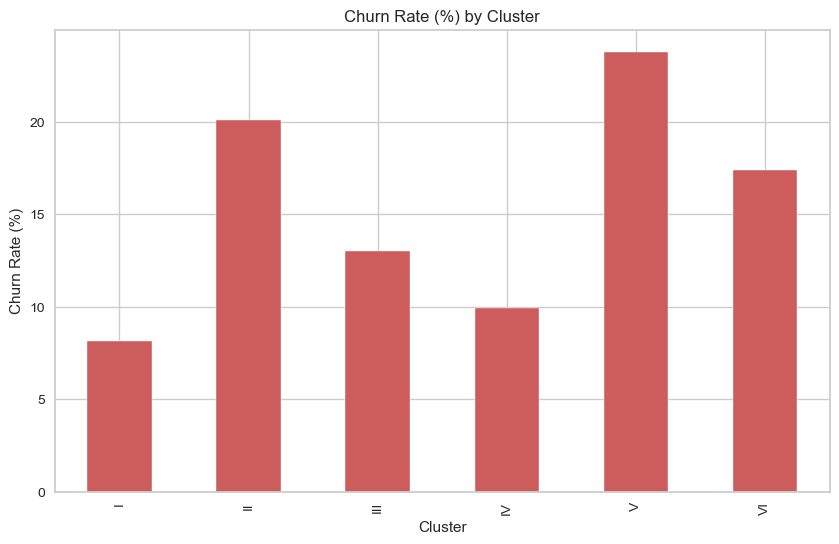

In [12]:
churn_by_cluster = df.groupby('Cluster_Label')['Attrition_Flag'].agg(['count', 'sum', 'mean'])
churn_by_cluster.columns = ['Total_Customers', 'Churned', 'Churn_Rate']
churn_by_cluster['Churn_Rate'] = (churn_by_cluster['Churn_Rate'] * 100).round(2)
churn_by_cluster = churn_by_cluster.reindex(['I', 'II', 'III', 'IV', 'V', 'VI'])

print(churn_by_cluster)

churn_by_cluster['Churn_Rate'].plot(kind='bar', color='indianred')
plt.title('Churn Rate (%) by Cluster')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Cluster')
plt.show()


## 6. Cluster Profiling — Mean Feature Values

This helps interpret *who* is in each cluster (e.g., high spenders, inactive customers,
young vs older customers, etc.) — useful context for the README/report.


In [13]:
profile_cols = [
    'Customer_Age', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct',
    'Avg_Utilization_Ratio'
]
profile_cols = [c for c in profile_cols if c in df.columns]

cluster_profile = df.groupby('Cluster_Label')[profile_cols].mean().reindex(
    ['I', 'II', 'III', 'IV', 'V', 'VI']
)
cluster_profile.round(3)


,Customer_Age,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct,Avg_Utilization_Ratio
Cluster_Label,,,,,,,,,,
I,-0.150,-0.143,5.009,2.370,1.453,0.210,0.476,0.182,0.427,0.296
II,-0.236,-0.214,2.178,2.263,2.097,0.247,0.461,0.309,0.509,0.256
III,-1.398,-1.273,4.176,2.209,2.735,0.163,0.464,0.201,0.418,0.312
IV,1.087,0.978,5.018,2.384,2.611,0.180,0.483,0.166,0.387,0.324
V,0.909,0.810,2.344,2.497,2.483,0.228,0.450,0.265,0.456,0.256
VI,-0.162,-0.117,4.793,2.357,3.526,0.227,0.450,0.174,0.406,0.268


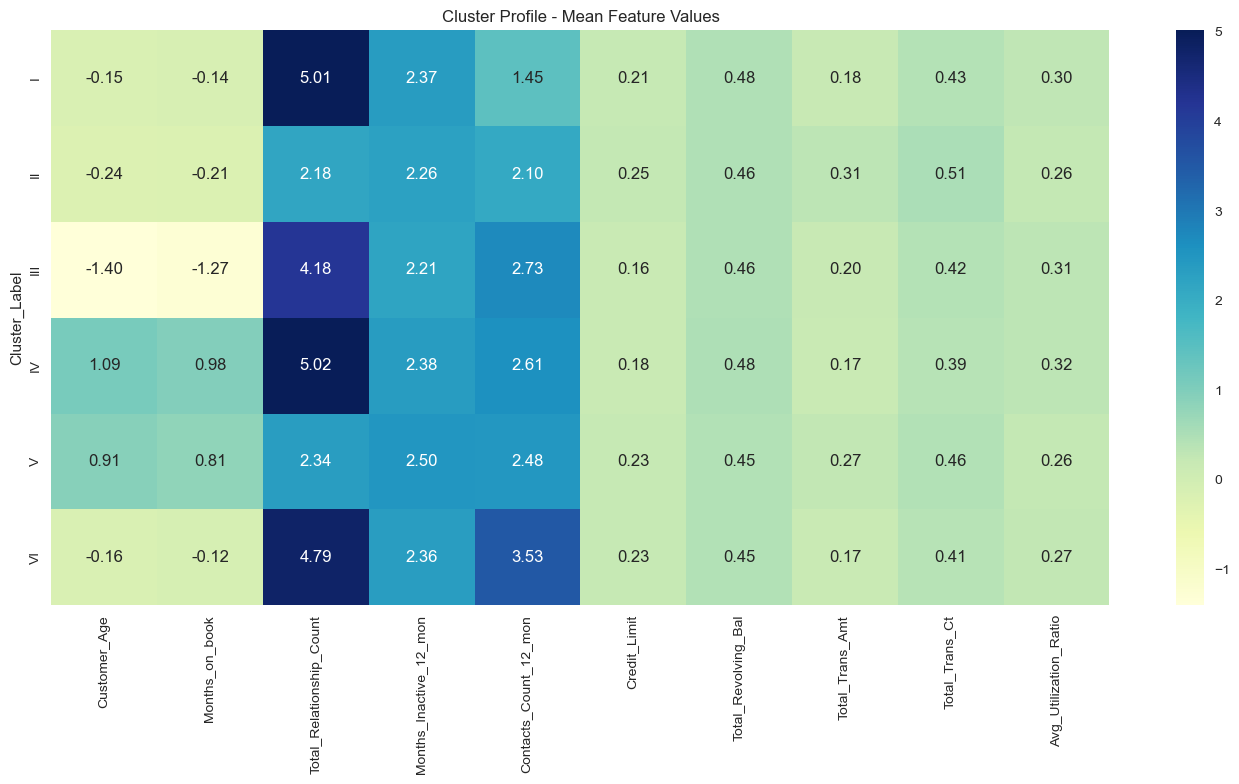

In [14]:
plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Profile - Mean Feature Values')
plt.tight_layout()
plt.show()


## 7. Data Balance Check per Cluster (Before SMOTE)

This reproduces Table 3 in the paper — showing how imbalanced churn is *within* each
cluster before any balancing is applied. SMOTE balancing itself happens in notebook 04.


In [15]:
balance_table = df.groupby('Cluster_Label')['Attrition_Flag'].value_counts().unstack()
balance_table.columns = ['Non_Churn', 'Churn']
balance_table = balance_table[['Churn', 'Non_Churn']]
balance_table['Ratio (1:x)'] = (balance_table['Non_Churn'] / balance_table['Churn']).round(1)
balance_table = balance_table.reindex(['I', 'II', 'III', 'IV', 'V', 'VI'])

# Add the "Original" (whole dataset) row for comparison
original_row = pd.DataFrame({
    'Churn': [df['Attrition_Flag'].sum()],
    'Non_Churn': [(df['Attrition_Flag'] == 0).sum()],
}, index=['Original'])
original_row['Ratio (1:x)'] = (original_row['Non_Churn'] / original_row['Churn']).round(1)

balance_table = pd.concat([original_row, balance_table])
balance_table


,Churn,Non_Churn,Ratio (1:x)
Original,1113,5968,5.4
I,97,1096,11.3
II,325,1291,4.0
III,124,829,6.7
IV,104,940,9.0
V,250,801,3.2
VI,213,1011,4.7


## 8. Save Segmented Dataset

In [16]:
import os
os.makedirs("../data/processed", exist_ok=True)

OUTPUT_PATH = "../data/processed/churn_segmented.csv"
df.to_csv(OUTPUT_PATH, index=False)

print(f"Segmented dataset saved to: {OUTPUT_PATH}")
print("Shape:", df.shape)
df.head()


Segmented dataset saved to: ../data/processed/churn_segmented.csv
Shape: (7081, 22)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Cluster,Cluster_Label
0,0,-0.167610,1,3,High School,Married,$60K - $80K,Blue,0.377234,5,1,3,0.340190,0.308701,0.345116,1.335,0.036260,0.258065,1.625,0.061,5,VI
1,0,0.329862,0,5,Graduate,Single,Less than $40K,Blue,1.002074,6,1,2,0.206112,0.343266,0.214093,1.541,0.044667,0.185484,3.714,0.105,0,I
2,0,0.578598,1,3,Graduate,Married,$80K - $120K,Blue,0.002330,4,1,0,0.059850,0.000000,0.098948,2.594,0.078753,0.080645,2.333,0.000,0,I
3,0,-0.789449,1,3,Uneducated,Married,$60K - $80K,Blue,-1.872192,5,1,0,0.099091,0.000000,0.136557,2.175,0.017501,0.145161,2.500,0.000,0,I
4,0,-0.291978,1,2,Graduate,Married,$40K - $60K,Blue,0.002330,3,1,2,0.077747,0.495431,0.079970,1.376,0.033057,0.112903,0.846,0.311,1,II


## Summary

- Used the **Elbow Method** to determine the optimal number of clusters → **k = 6**
  (matches the paper).
- Fit **K-Means** and assigned each customer to one of 6 clusters (labeled I–VI to
  match the paper's naming).
- Profiled each cluster's churn rate and average feature values to understand customer
  segments.
- Confirmed each cluster is also imbalanced (churn is always the minority class),
  consistent with Table 3 in the paper.
- Saved `data/processed/churn_segmented.csv`, which now contains the original features
  **plus** `Cluster` / `Cluster_Label` columns.

➡️ **Next:** `04_modeling.ipynb` — apply SMOTE (overall and per-cluster), then train and
evaluate KNN, Logistic Regression, Decision Tree, Random Forest, and SVM — comparing
results **with vs. without customer segmentation**.
